# FQL Succession P2 — M-uni-noise (Sub-optimal, Noise-widened Unimodal)

> Sub-optimal × Multi-modal 矩阵的 **sub-opt ✓ × uni ✓** 角(audit advisory caveat)
>
> 文档锚点:[`docs/fql_succession_p2_main_spec.md`](../docs/fql_succession_p2_main_spec.md) v1.3 + [`docs/fql_succession_p2_collection_log.md`](../docs/fql_succession_p2_collection_log.md)
>
> 参考 notebook 风格:[`notebooks/rebrac_c1_asym_critic_ablation.ipynb`](rebrac_c1_asym_critic_ablation.ipynb)

## 前传 — Gate B 已知事实

Gate B(P1 finalization 2026-05-12)在 E-uni 上跑 4 run(rebrac + fql × seed [42, 0]),test success Δ_E-uni = -4.4pp(FQL 略低于 ReBRAC,marginal)。P2 在 100-episode test manifest(ep100,Bug 2 fix)下重 collect E-uni + 新 collect M-uni-noise / M-multi-mix,以 12-run primary(3 cell × 2 algo × 2 seed [42, 0])跑完整 iff verdict。

## 本 notebook scope

- **Cell**:M-uni-noise (Sub-optimal, Noise-widened Unimodal)
- **Dataset**:`offline_data/fql_succession/m_uni_noise_eps0p5_1000`
- **Collection**:privileged policy + ε=0.5 Gaussian action noise × 1000 ep(P2 sprint 0 新 collect);success_rate=0.632 ✓ Band A target [0.50, 0.75]
- **预期 verdict**:**NULL** — FQL ≈ ReBRAC on sub-opt × unimodal(paper claim:FQL 优势需要 multi-modal 触发)

**该 cell 角色**:M-uni-noise 是 FQL claim 的 **discriminator**——sub-optimal(success ≈ 63%)但物理上仍是 single policy + Gaussian noise widening(unimodal by construction,per `policy_mixture` metadata)。**Audit advisory caveat**(per spec v1.3 §3.0 + §10.5):A2 audit p_≥2=0.996(GMM false-positive on noise-widened single policy,**不阻塞 cell 使用**,cell assignment 由 collection protocol 决定)。Paper §method appendix 引用 §10.5 GMM caveat 段透明披露。

## 隔离表(本 cell vs 另两 cell)

| Cell | Optimality | Modality | Paper claim 预期 |
|---|---|---|---|
| E-uni | optimal (success 0.985) | unimodal (single privileged) | NULL (FQL ≈ ReBRAC) |
| **M-uni-noise** ✓ | sub-opt (success 0.632) | unimodal (noise-widened, audit advisory) | NULL (FQL ≈ ReBRAC) |
| M-multi-mix | sub-opt (~0.83 mix) | multi-modal (2-policy, audit confirms) | **POSITIVE** (FQL > ReBRAC ≥5pp) |

## Verdict 规则(effect-size + 方向一致性 primary,from spec §5.4)

**阈值**:`δ_null = 0.03`(3pp,null band)+ `δ_signal = 0.05`(5pp,signal threshold)+ **gray band [3pp, 5pp]** 或方向不一致 → 加 seed 7 扩 n_seeds=3 再判。

**本 cell 预期 verdict 方向**:`null` — 若 NULL → paper claim 强证:不是 sub-optimal 触发 FQL 优势,而是 multi-modality 触发。若 POSITIVE → paper claim 弱化为「FQL 在 sub-optimal 数据上普遍占优」(less specific)。

| 本 cell verdict | 判定 | 后续 |
|---|---|---|
| `\|Δ\| < 0.03` AND \|diff_seed\| < 0.04 both | **NULL CONFIRMED** ✓ | 符合 paper claim 预期 |
| `Δ ≥ 0.05` 同方向 | **UNEXPECTED POSITIVE** ⚠ | paper claim 失败(FQL 也在本 cell 赢)→ sprint 1 重审 |
| 3pp ≤ \|Δ\| < 5pp 或方向不一致 | **GRAY** | 加 seed 7 扩 n_seeds=3,在 sprint 1 跑 |

**c4 stability monitor**(per spec §5.6,n=2 threshold = -0.01549):aggregated slope = mean of last-30%-eval-pts linregress slope per seed。FQL c4 FAIL → §7 verdict 附 caveat。

## 1. 环境 sanity

确认 Colab L4 + CUDA + Drive 挂载 + `%cd` 进 project root。

In [1]:
!nvidia-smi | head -15
!lscpu | head -10

Thu May 21 12:52:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
print(f'torch={torch.__version__}  CUDA available={torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'device={torch.cuda.get_device_name(0)}')

torch=2.10.0+cu128  CUDA available=True
device=NVIDIA L4


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
%cd '/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5'
!pwd && ls scripts/train_offline.py scripts/evaluate_offline.py

/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5
/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5
scripts/evaluate_offline.py  scripts/train_offline.py


## 2. 通用配置

定义 `CELL_ID` / `DATASET` / `FLOW` / `MANIFEST` / `CHECKPOINT_ROOT` / `RESULTS_ROOT` + `REBRAC_FLAGS` / `FQL_FLAGS` + `TRAIN_SEEDS=[42, 0]`(primary,n=2)。Helper 路径函数定义在此处,§4 / §5 / §6 共用。

`CHECKPOINT_ROOT`(大文件,留 Drive)和 `RESULTS_ROOT`(小文件,可 sync 回 local 绘图)**分树存储**(per spec §4.2 D21)。

In [6]:
import os
import shutil
from pathlib import Path

# ---- per-cell config ----
CELL_ID  = 'm_uni_noise'
DATASET  = 'offline_data/fql_succession/m_uni_noise_eps0p5_1000'

# ---- shared (3 notebooks 一致) ----
FLOW     = 'wake_data/wake_v8_U1p00_Re150_D12p00_dx0p60_Ti5pct_1200f_roi.npy'
MANIFEST = 'benchmarks/single_u10_cross_tgt15_ep100.json'

PROBE_LAYOUT   = 's0'
HISTORY_LENGTH = 4
TARGET_SPEED   = 1.5
TASK_GEOMETRY  = 'cross_stream'
OBJECTIVE      = 'arrival_v2'

TOTAL_STEPS    = 200_000
BATCH_SIZE     = 256
EVAL_EVERY     = 10_000
EVAL_EPISODES  = 100
TEST_EPISODES  = 100
EVAL_NUM_WORKERS = 6

# ReBRAC anchor (β1=4.0, β2=2.0) + critic LayerNorm only (Gate B frozen)
REBRAC_FLAGS = (
    '--actor-penalty-coef 4.0 --critic-penalty-coef 2.0 '
    '--critic-layernorm --no-actor-layernorm'
)

# FQL teacher + student distill (Gate B frozen)
FQL_FLAGS = (
    '--flow-steps 10 --distill-alpha-bc 1.0 '
    '--teacher-lr 3e-4 --flow-time-embed-dim 32'
)

# n=2 primary; 扩 n=3 时改为 [42, 0, 7] 并重跑本 notebook
TRAIN_SEEDS = [42, 0]
ALGOS = ['rebrac', 'fql']

# ---- paths ----
CHECKPOINT_ROOT = Path(f'checkpoints/fql_succession/p2/{CELL_ID}')
RESULTS_ROOT    = Path(f'results/fql_succession/p2/{CELL_ID}')
TEST_DIR        = RESULTS_ROOT / 'test'
CURVES_DIR      = RESULTS_ROOT / 'training_curves'

# Mirror these 4 small files from checkpoints → results/training_curves/
MIRROR_FILES = ('train_log.jsonl', 'eval_log.csv', 'trainer_state.json', 'train_config.txt')

def save_dir(algo: str, seed: int) -> Path:
    return CHECKPOINT_ROOT / f'{algo}_seed{seed}'

def test_json(algo: str, seed: int) -> Path:
    return TEST_DIR / f'{algo}_seed{seed}.json'

def mirror_dir(algo: str, seed: int) -> Path:
    return CURVES_DIR / f'{algo}_seed{seed}'

print(f'CELL_ID         = {CELL_ID}')
print(f'DATASET         = {DATASET}')
print(f'CHECKPOINT_ROOT = {CHECKPOINT_ROOT}')
print(f'RESULTS_ROOT    = {RESULTS_ROOT}')
print(f'TRAIN_SEEDS     = {TRAIN_SEEDS}')
print(f'ALGOS           = {ALGOS}  ({len(ALGOS)*len(TRAIN_SEEDS)} runs total)')

CELL_ID         = m_uni_noise
DATASET         = offline_data/fql_succession/m_uni_noise_eps0p5_1000
CHECKPOINT_ROOT = checkpoints/fql_succession/p2/m_uni_noise
RESULTS_ROOT    = results/fql_succession/p2/m_uni_noise
TRAIN_SEEDS     = [42, 0]
ALGOS           = ['rebrac', 'fql']  (4 runs total)


## 3. Pre-flight — dataset / manifest / flow sanity

在跑 4 run 之前确认:
1. **Dataset 路径存在** + `transitions.npz` + `metadata.json` 都 readable
2. **`policy_mixture` metadata 符合 cell 定义**(本 cell 期望:[{'policy': 'privileged', 'weight': 1.0}])— 这是 Gate C.2 cell-construction integrity check(per spec v1.3 §6.2,不依赖 audit verdict)
3. **Manifest + flow 存在**
4. **Transition 数量 sanity**(本 cell 期望 ~{n_tx} transitions)

**如果 §3 任一 assert FAIL → 停止,不要进 §4 训练**(可能 dataset 错配)。

In [7]:
import json
import numpy as np

DATASET_DIR  = Path(DATASET)
TRANSITIONS  = DATASET_DIR / 'transitions.npz'
METADATA     = DATASET_DIR / 'metadata.json'
MANIFEST_P   = Path(MANIFEST)
FLOW_P       = Path(FLOW)

# ---- existence checks ----
for p in [DATASET_DIR, TRANSITIONS, METADATA, MANIFEST_P, FLOW_P]:
    assert p.exists(), f'[FAIL] missing path: {p}'
print('[ok] all 5 required paths exist')

# ---- metadata: policy_mixture sanity (Gate C.2 cell-construction integrity) ----
meta = json.loads(METADATA.read_text())
print(f'\n[metadata] {METADATA}')
for k in ['policy_mixture', 'action_noise_std', 'num_episodes', 'num_transitions',
          'probe_layout', 'task_geometry', 'objective', 'mean_return', 'success_rate']:
    if k in meta:
        v = meta[k]
        if isinstance(v, float):
            print(f'  {k}: {v:.4f}')
        else:
            print(f'  {k}: {v}')

# ---- cell-specific expected check ----
# Expected: policy_mixture ≈ "[{'policy': 'privileged', 'weight': 1.0}]"
# Expected: action_noise_std ≈ 0.5
# Expected: num_transitions ≈ 120525

n_tx = meta.get('num_transitions', None)
if n_tx is not None:
    assert abs(n_tx - 120525) < 120525 * 0.1, (
        f'[WARN] num_transitions {n_tx} 偏离预期 120525 >10%; '
        f'check dataset path correctness'
    )
    print(f'[ok] num_transitions sanity: {n_tx}')

# ---- transitions.npz key dump ----
with np.load(TRANSITIONS) as data:
    print(f'\n[transitions.npz] keys = {list(data.keys())}')
    for k in data.keys():
        arr = data[k]
        print(f'  {k}: shape={arr.shape}, dtype={arr.dtype}')

# ---- manifest sanity ----
manifest_data = json.loads(MANIFEST_P.read_text())
n_ep_in_manifest = len(manifest_data.get('episodes', []))
print(f'\n[manifest] {MANIFEST_P}  episodes={n_ep_in_manifest}')
assert n_ep_in_manifest >= TEST_EPISODES, (
    f'[FAIL] manifest only has {n_ep_in_manifest} ep, need >= {TEST_EPISODES}')
print(f'[ok] manifest covers >= {TEST_EPISODES} episodes')

print('\n[PRE-FLIGHT PASS] ready to train.')

[ok] all 5 required paths exist

[metadata] offline_data/fql_succession/m_uni_noise_eps0p5_1000/metadata.json
  policy_mixture: [{'policy': 'privileged', 'weight': 1.0}]
  action_noise_std: 0.5000
  num_episodes: 1000
  num_transitions: 120525
  probe_layout: s0
  task_geometry: cross_stream
  objective: arrival_v2
  mean_return: -2.6140
  success_rate: 0.6320
[ok] num_transitions sanity: 120525

[transitions.npz] keys = ['obs', 'actions', 'next_actions', 'rewards', 'costs', 'next_obs', 'dones', 'terminateds', 'truncateds', 'terminal_reason_codes', 'behavior_policy_codes', 'privileged_obs', 'next_privileged_obs']
  obs: shape=(120525, 48), dtype=float32
  actions: shape=(120525, 2), dtype=float32
  next_actions: shape=(120525, 2), dtype=float32
  rewards: shape=(120525,), dtype=float32
  costs: shape=(120525,), dtype=float32
  next_obs: shape=(120525, 48), dtype=float32
  dones: shape=(120525,), dtype=float32
  terminateds: shape=(120525,), dtype=float32
  truncateds: shape=(120525,), 

## 4. 训练 — 2 algo × 2 seeds = 4 runs

`!python` magic 实时 stream(per spec Bug 4 mitigation);路径单引号包裹(per Bug 5,handles Colab `Colab Notebooks` Drive 空格)。

**Skip-resume**:`agent_final.pt` 存在则 skip 该 (algo, seed) 训练。**Mirror**:每 run 训完后立刻 mirror 4 个小文件(`train_log.jsonl`, `eval_log.csv`, `trainer_state.json`, `train_config.txt`)到 `results/.../training_curves/`,便于本机 sync 后画 learning curve(per spec §4.2 D21)。

**`--skip-final-eval`**:训练阶段不跑 final eval,由 §5 独立 `evaluate_offline` 跑 100-ep test(per spec §4.2 two-step protocol)。

**预期 wallclock**:每 run ~30-45 min(L4,200k steps + 20 in-training eval pts × 100 ep)。4 runs 串行 ~2-3h。

In [8]:
import time

t_start_train = time.time()

for algo in ALGOS:
    ALGO_FLAGS = REBRAC_FLAGS if algo == 'rebrac' else FQL_FLAGS
    for seed in TRAIN_SEEDS:
        sd = save_dir(algo, seed)
        sd_str = str(sd)

        if (sd / 'agent_final.pt').exists():
            print(f'[skip-train] {algo} seed={seed} (agent_final.pt exists at {sd})')
            continue

        sd.mkdir(parents=True, exist_ok=True)
        print(f'\n{"=" * 72}')
        print(f'  train {algo} seed={seed} → {sd}')
        print(f'{"=" * 72}')
        t0 = time.time()

        !python -m scripts.train_offline \
            --algo {algo} \
            --offline-data '{DATASET}/transitions.npz' \
            --flow '{FLOW}' \
            --manifest '{MANIFEST}' \
            --probe-layout {PROBE_LAYOUT} \
            --history-length {HISTORY_LENGTH} \
            --target-speed {TARGET_SPEED} \
            --task-geometry {TASK_GEOMETRY} \
            --objective {OBJECTIVE} \
            --total-steps {TOTAL_STEPS} \
            --batch-size {BATCH_SIZE} \
            --eval-every {EVAL_EVERY} \
            --eval-episodes {EVAL_EPISODES} \
            {ALGO_FLAGS} \
            --skip-final-eval \
            --seed {seed} \
            --save-dir '{sd_str}' \
            --device cuda

        print(f'[train done] {algo} seed={seed} in {(time.time() - t0) / 60:.1f} min')

print(f'\n[all train] total = {(time.time() - t_start_train) / 60:.1f} min')

# ---- Mirror small files (idempotent overwrite) ----
print(f'\n{"=" * 72}')
print('  mirror training curves → results/.../training_curves/')
print(f'{"=" * 72}')

for algo in ALGOS:
    for seed in TRAIN_SEEDS:
        src_dir = save_dir(algo, seed)
        dst_dir = mirror_dir(algo, seed)
        dst_dir.mkdir(parents=True, exist_ok=True)
        n_copied = 0
        for fname in MIRROR_FILES:
            src = src_dir / fname
            if src.exists():
                shutil.copy2(src, dst_dir / fname)
                n_copied += 1
        marker = '✓' if n_copied == len(MIRROR_FILES) else '⚠'
        print(f'  {marker} {algo}_seed{seed}: {n_copied}/{len(MIRROR_FILES)} → {dst_dir}')


  train rebrac seed=42 → checkpoints/fql_succession/p2/m_uni_noise/rebrac_seed42
[offline] algo=rebrac transitions=120525 obs_dim=48 action_dim=2 protocol=deployable tensor_replay=on eval_workers=1 sampling=uniform total_steps=200000
[train] step=1 q=-0.863 critic=48.143 actor=6.024 bc=1.256 lambda=1.158 critic_pen=1.304
[train] step=1000 q=-5.295 critic=209.683 actor=1.894 bc=0.267 lambda=0.156 critic_pen=0.419
[train] step=2000 q=-5.422 critic=22.006 actor=1.525 bc=0.233 lambda=0.109 critic_pen=0.315
[train] step=3000 q=-8.554 critic=3.748 actor=1.840 bc=0.265 lambda=0.091 critic_pen=0.334
[train] step=4000 q=-8.611 critic=122.325 actor=1.535 bc=0.248 lambda=0.063 critic_pen=0.301
[train] step=5000 q=-8.627 critic=14.140 actor=1.390 bc=0.216 lambda=0.061 critic_pen=0.310
[train] step=6000 q=-12.226 critic=49.532 actor=1.381 bc=0.203 lambda=0.047 critic_pen=0.281
[train] step=7000 q=-17.745 critic=7.177 actor=1.552 bc=0.215 lambda=0.039 critic_pen=0.270
[train] step=8000 q=-17.421 cr

## 5. Test eval — 100-episode 在 ep100 manifest 上

用 `scripts.evaluate_offline` 加载每个 (algo, seed) 的 `agent_final.pt`,在 100-episode test manifest 上跑评估。结果写到 `results/.../test/{algo}_seed{S}.json`(per spec §4.2 + §9.3.1)。

**Skip-resume**:test json 存在则 skip。
**并行**:6 worker × CPU(与 broad bash 一致),~3-5 min/run。

In [9]:
import time

TEST_DIR.mkdir(parents=True, exist_ok=True)

t_start_eval = time.time()

for algo in ALGOS:
    for seed in TRAIN_SEEDS:
        sd = save_dir(algo, seed)
        sd_str = str(sd)
        out_path = test_json(algo, seed)
        out_path_str = str(out_path)

        if out_path.exists():
            print(f'[skip-eval] {algo} seed={seed}: {out_path}')
            continue

        if not (sd / 'agent_final.pt').exists():
            print(f'[warn] missing agent_final.pt at {sd} — training not done?')
            continue

        print(f'\n{"=" * 72}')
        print(f'  eval {algo} seed={seed} → {out_path}')
        print(f'{"=" * 72}')
        t0 = time.time()

        !python -m scripts.evaluate_offline \
            --checkpoint '{sd_str}' \
            --manifest '{MANIFEST}' \
            --episodes {TEST_EPISODES} \
            --num-workers {EVAL_NUM_WORKERS} \
            --worker-device cpu \
            --device cuda \
            --output-json '{out_path_str}'

        print(f'[eval done] {algo} seed={seed} in {(time.time() - t0) / 60:.1f} min')

print(f'\n[all eval] total = {(time.time() - t_start_eval) / 60:.1f} min')


  eval rebrac seed=42 → results/fql_succession/p2/m_uni_noise/test/rebrac_seed42.json
reward_objective      : arrival_v2
energy_cost_gain      : 0.000000
safety_cost_gain      : 0.000000
episodes              : 100
success_rate          : 68.0%
avg_return            : 27.73 +/- 147.81
avg_safety_cost       : 8.844 +/- 7.293
avg_time_s            : 53.09 +/- 11.63
avg_time_s_success    : 53.62
avg_energy            : 39851.87 +/- 8843.27
avg_path_length_m     : 54.52 +/- 8.98
avg_progress_ratio    : 0.824 +/- 0.142
avg_path_efficiency   : 0.669 +/- 0.174
termination           : {'goal': 68, 'out_of_bounds': 32}
benchmark_manifest    : benchmarks/single_u10_cross_tgt15_ep100.json
[eval done] rebrac seed=42 in 1.4 min

  eval rebrac seed=0 → results/fql_succession/p2/m_uni_noise/test/rebrac_seed0.json
reward_objective      : arrival_v2
energy_cost_gain      : 0.000000
safety_cost_gain      : 0.000000
episodes              : 100
success_rate          : 73.0%
avg_return            : 38.39 

## 6. 三向对比 — 4 run × test json + learning curves

**Guard**:所有 4 个 test json 都存在才进 §6 / §7(per spec §9.3.2)。

**输出**:
1. DataFrame:per (algo, seed) 的 `success_rate`,`mean_return`,`safety_cost`,`path_efficiency`,`progress_ratio`,termination 分布(goal / timeout / oob)
2. Aggregate table:per algo(mean ± std over 2 seeds)
3. Inline matplotlib:**success rate bar**(rebrac vs fql,with seed dots)+ **learning curve**(eval success vs train_step,4 lines,from eval_log.csv mirror)

[ok] all 4 test json present
[per-seed test results]
  algo  seed  success_rate  mean_return  return_std  safety_cost  path_eff  progress  goal_pct  timeout_pct  oob_pct
rebrac    42        0.6800      27.7274    147.8125       8.8441    0.6688    0.8244    0.6800       0.0000   0.3200
rebrac     0        0.7300      38.3857    141.8344      10.9939    0.6456    0.8262    0.7300       0.0000   0.2700
   fql    42        0.9100     107.5482     93.6451       4.9470    0.8219    0.8914    0.9100       0.0000   0.0900
   fql     0        0.9100     108.0406     96.5045       4.1135    0.8074    0.8782    0.9100       0.0000   0.0900

[per-algo aggregate (mean ± std over n=2 seeds)]
  algo  success_mean  success_std  return_mean  return_std  safety_mean  path_eff_mean  goal_pct_mean  timeout_pct_mean  oob_pct_mean
   fql        0.9100       0.0000     107.7944      0.2462       4.5302         0.8147         0.9100            0.0000        0.0900
rebrac        0.7050       0.0250      33.05

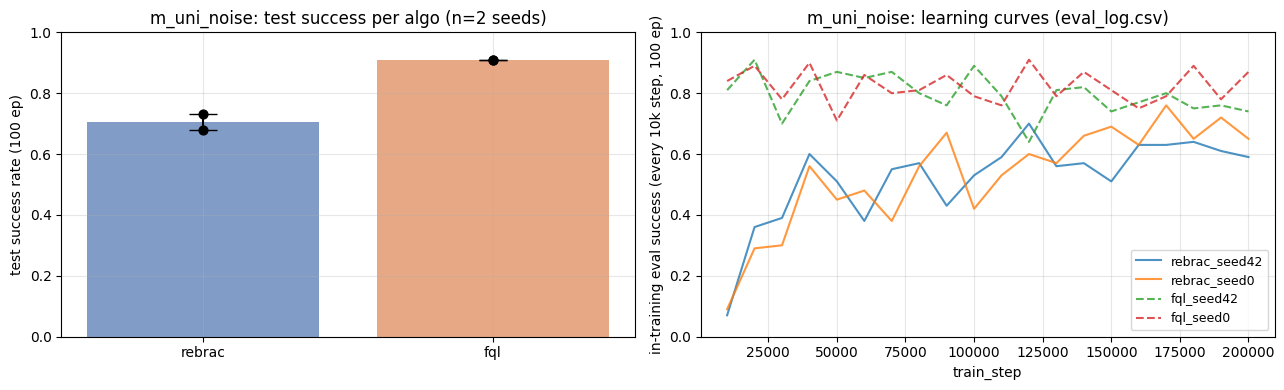

In [10]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- guard ----
missing = [(a, s) for a in ALGOS for s in TRAIN_SEEDS if not test_json(a, s).exists()]
if missing:
    raise RuntimeError(
        f'[not ready] {len(missing)} runs pending: '
        + ', '.join(f'{a}_seed{s}' for a, s in missing)
    )
print(f'[ok] all {len(ALGOS) * len(TRAIN_SEEDS)} test json present')

# ---- read 4 test json ----
rows = []
for algo in ALGOS:
    for seed in TRAIN_SEEDS:
        p = test_json(algo, seed)
        d = json.loads(p.read_text(encoding='utf-8'))
        n = max(int(d.get('num_eval_episodes', TEST_EPISODES)), 1)
        term = d.get('eval_termination_counts', {})
        rows.append({
            'algo': algo,
            'seed': seed,
            'success_rate': d['eval_success_rate'],
            'mean_return':  d['eval_return'],
            'return_std':   d.get('eval_return_std', float('nan')),
            'safety_cost':  d['eval_safety_cost'],
            'path_eff':     d.get('eval_path_efficiency', float('nan')),
            'progress':     d.get('eval_progress_ratio', float('nan')),
            'goal_pct':     term.get('goal', 0) / n,
            'timeout_pct':  term.get('timeout', 0) / n,
            'oob_pct':      term.get('out_of_bounds', 0) / n,
        })
df = pd.DataFrame(rows)
print('[per-seed test results]')
print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# ---- aggregate per algo (mean ± std over 2 seeds) ----
agg = df.groupby('algo').agg(
    success_mean=('success_rate', 'mean'),
    success_std=('success_rate', lambda x: x.std(ddof=0)),
    return_mean=('mean_return', 'mean'),
    return_std=('mean_return', lambda x: x.std(ddof=0)),
    safety_mean=('safety_cost', 'mean'),
    path_eff_mean=('path_eff', 'mean'),
    goal_pct_mean=('goal_pct', 'mean'),
    timeout_pct_mean=('timeout_pct', 'mean'),
    oob_pct_mean=('oob_pct', 'mean'),
).reset_index()
print('\n[per-algo aggregate (mean ± std over n=2 seeds)]')
print(agg.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# ---- plot 1: success rate bar (rebrac vs fql, with seed dots) ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
x_pos = np.arange(len(ALGOS))
means = [agg.query(f'algo == {a!r}')['success_mean'].iloc[0] for a in ALGOS]
stds  = [agg.query(f'algo == {a!r}')['success_std'].iloc[0]  for a in ALGOS]
ax.bar(x_pos, means, yerr=stds, capsize=10, color=['#4C72B0', '#DD8452'], alpha=0.7)
# overlay per-seed dots
for i, algo in enumerate(ALGOS):
    seed_succ = df.query(f'algo == {algo!r}')['success_rate'].values
    ax.scatter([i] * len(seed_succ), seed_succ, color='black', zorder=10, s=40)
ax.set_xticks(x_pos)
ax.set_xticklabels(ALGOS)
ax.set_ylabel('test success rate (100 ep)')
ax.set_title(f'{CELL_ID}: test success per algo (n={len(TRAIN_SEEDS)} seeds)')
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)

# ---- plot 2: learning curve from eval_log.csv ----
ax = axes[1]
for algo in ALGOS:
    for seed in TRAIN_SEEDS:
        csv_p = mirror_dir(algo, seed) / 'eval_log.csv'
        if not csv_p.exists():
            continue
        eval_df = pd.read_csv(csv_p)
        # dedup by train_step (keep last)
        eval_df = eval_df.drop_duplicates(subset='train_step', keep='last')
        label = f'{algo}_seed{seed}'
        style = '-' if algo == 'rebrac' else '--'
        ax.plot(eval_df['train_step'], eval_df['eval_success_rate'],
                style, label=label, alpha=0.8)
ax.set_xlabel('train_step')
ax.set_ylabel('in-training eval success (every 10k step, 100 ep)')
ax.set_title(f'{CELL_ID}: learning curves (eval_log.csv)')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 自动 verdict — effect-size + 方向一致性(per spec §5.4)

**本 cell 预期方向**:`null` — 若 NULL → paper claim 强证:不是 sub-optimal 触发 FQL 优势,而是 multi-modality 触发。若 POSITIVE → paper claim 弱化为「FQL 在 sub-optimal 数据上普遍占优」(less specific)。

**阈值**:`δ_null = 0.03` + `δ_signal = 0.05` + gray band [3pp, 5pp]。

**输出**:
1. `Δ = mean(success_fql) - mean(success_rebrac)` over seeds
2. paired diff per seed:`Δ_seed = success_fql_seed - success_rebrac_seed`
3. 方向一致性:两 seed paired diff 同号 ?
4. c4 stability(per spec §5.6,n=2 threshold = −0.01549,from `eval_log.csv` last 30%)
5. **Verdict**:NULL / POSITIVE / GRAY(per §5.4 表)

In [11]:
import numpy as np
from scipy.stats import linregress

DELTA_NULL = 0.03
DELTA_SIGNAL = 0.05
C4_THRESHOLD_N2 = -0.01549  # per spec §5.6 n=2 Option α
EXPECTED_DIRECTION = 'null'  # 'null' or 'positive'

# ---- 1. Aggregate success per algo ----
succ_rebrac = df.query("algo == 'rebrac'")['success_rate'].values
succ_fql    = df.query("algo == 'fql'")['success_rate'].values
delta_mean = succ_fql.mean() - succ_rebrac.mean()

# ---- 2. Paired diff per seed ----
paired = {}
for seed in TRAIN_SEEDS:
    s_r = df.query(f'algo == "rebrac" and seed == {seed}')['success_rate'].iloc[0]
    s_f = df.query(f'algo == "fql" and seed == {seed}')['success_rate'].iloc[0]
    paired[seed] = s_f - s_r

all_positive = all(d > 0 for d in paired.values())
all_negative = all(d < 0 for d in paired.values())
all_near_zero = all(abs(d) < 0.04 for d in paired.values())
direction_consistent = all_positive or all_negative or all_near_zero

# ---- 3. c4 stability per algo ----
c4 = {}
for algo in ALGOS:
    slopes = []
    for seed in TRAIN_SEEDS:
        csv_p = mirror_dir(algo, seed) / 'eval_log.csv'
        if not csv_p.exists():
            continue
        ed = pd.read_csv(csv_p).drop_duplicates(subset='train_step', keep='last')
        # last 30% of eval points
        n_pts = max(int(round(len(ed) * 0.3)), 3)
        tail = ed.tail(n_pts)
        if len(tail) >= 3:
            slope, *_ = linregress(tail['train_step'], tail['eval_success_rate'])
            slopes.append(slope)
    if slopes:
        c4[algo] = {
            'per_seed_slopes': slopes,
            'agg_slope': float(np.mean(slopes)),
            'verdict': 'PASS' if np.mean(slopes) >= C4_THRESHOLD_N2 else 'FAIL',
        }

# ---- 4. Verdict logic (per spec §5.4) ----
print('=' * 72)
print(f'  CELL_ID = {CELL_ID}   expected = {EXPECTED_DIRECTION}')
print('-' * 72)
print(f'  ReBRAC success mean = {succ_rebrac.mean():.4f}   per-seed = {dict(zip(TRAIN_SEEDS, succ_rebrac.tolist()))}')
print(f'  FQL    success mean = {succ_fql.mean():.4f}   per-seed = {dict(zip(TRAIN_SEEDS, succ_fql.tolist()))}')
print(f'  Δ (FQL − ReBRAC) mean = {delta_mean:+.4f} ({delta_mean*100:+.2f} pp)')
print(f'  paired diff per seed  = {dict((s, round(d, 4)) for s, d in paired.items())}')
print(f'  direction_consistent  = {direction_consistent} '
      f'(all_pos={all_positive}, all_neg={all_negative}, all_near_zero={all_near_zero})')
print('-' * 72)
print('  c4 stability monitor (per spec §5.6, n=2 threshold = -0.01549):')
for algo, info in c4.items():
    print(f'    {algo}: agg_slope = {info["agg_slope"]:+.5f}   verdict = {info["verdict"]}'
          f'   per-seed = {[round(s, 5) for s in info["per_seed_slopes"]]}')
print('-' * 72)

# ---- 5. Verdict decision ----
abs_delta = abs(delta_mean)
if EXPECTED_DIRECTION == 'null':
    # paper wants null: |Δ| < 0.03 AND seed diffs all near zero
    if abs_delta < DELTA_NULL and all_near_zero:
        verdict = 'NULL CONFIRMED ✓ (符合 paper claim 预期)'
        next_step = 'log to verdict report; proceed with other cells'
    elif delta_mean >= DELTA_SIGNAL and all_positive:
        verdict = 'UNEXPECTED POSITIVE ⚠ (FQL 在本 cell 也赢 — paper claim 失败)'
        next_step = (
            'paper claim 失败:FQL 不止在 multi-modal 赢,在本 cell 也赢 → '
            'sprint 1 加 seed 7;若仍 positive 则 paper claim 重写'
        )
    elif delta_mean <= -DELTA_SIGNAL and all_negative:
        verdict = 'UNEXPECTED NEGATIVE ⚠ (ReBRAC 在本 cell 显著强于 FQL — paper claim 弱化)'
        next_step = (
            'paper claim 弱化:本 cell 上 ReBRAC > FQL,可能数据 quality 高时 ReBRAC 占优 → '
            'sprint 1 加 seed 7 后写 caveat 段'
        )
    else:
        verdict = 'GRAY (3pp ≤ |Δ| < 5pp 或方向不一致) — 加 seed 7'
        next_step = '扩 n_seeds=3 [42, 0, 7],在 sprint 1 跑'
elif EXPECTED_DIRECTION == 'positive':
    # paper wants positive: Δ ≥ 0.05 AND both seeds positive
    if delta_mean >= DELTA_SIGNAL and all_positive:
        verdict = 'POSITIVE CONFIRMED ✓ (符合 paper claim 预期)'
        next_step = 'paper claim 主结论确证:本 cell 是 iff 的右侧(FQL > ReBRAC on sub-opt × multi-modal)'
    elif abs_delta < DELTA_NULL:
        verdict = 'NULL ❌ (paper claim 失败 — FQL ≯ ReBRAC on multi-modal)'
        next_step = (
            'paper claim 主结论失败:本 cell 是 iff 主证据,如果 NULL → iff 不成立 → '
            'sprint 1 加 seed 7;若仍 NULL 则 paper claim 重写或重设计 dataset'
        )
    elif not all_positive:
        verdict = 'GRAY (mixed direction across seeds) — 加 seed 7'
        next_step = '扩 n_seeds=3 [42, 0, 7];方向一致性 critical for paper claim'
    else:
        verdict = 'GRAY (3pp ≤ Δ < 5pp,方向一致但 effect size 小) — 加 seed 7'
        next_step = '扩 n_seeds=3 [42, 0, 7];考虑 paper 弱化措辞'
else:
    verdict = f'UNKNOWN expected direction {EXPECTED_DIRECTION!r}'
    next_step = 'spec error: §0 verdict 规则需要更新'

print(f'  VERDICT  : {verdict}')
print(f'  NEXT     : {next_step}')

# ---- 6. c4 caveat ----
fql_c4 = c4.get('fql', {}).get('verdict')
if fql_c4 == 'FAIL':
    print(f'  CAVEAT   : FQL c4 FAIL (slope < -0.01549) — paper 写 "FQL stability marginally fails in {CELL_ID}"')
elif fql_c4 == 'PASS':
    print(f'  CAVEAT   : FQL c4 PASS — stability monitor OK')
print('=' * 72)

  CELL_ID = m_uni_noise   expected = null
------------------------------------------------------------------------
  ReBRAC success mean = 0.7050   per-seed = {42: 0.68, 0: 0.73}
  FQL    success mean = 0.9100   per-seed = {42: 0.91, 0: 0.91}
  Δ (FQL − ReBRAC) mean = +0.2050 (+20.50 pp)
  paired diff per seed  = {42: np.float64(0.23), 0: np.float64(0.18)}
  direction_consistent  = True (all_pos=True, all_neg=False, all_near_zero=False)
------------------------------------------------------------------------
  c4 stability monitor (per spec §5.6, n=2 threshold = -0.01549):
    rebrac: agg_slope = +0.00000   verdict = PASS   per-seed = [np.float64(0.0), np.float64(-0.0)]
    fql: agg_slope = +0.00000   verdict = PASS   per-seed = [np.float64(-0.0), np.float64(0.0)]
------------------------------------------------------------------------
  VERDICT  : UNEXPECTED POSITIVE ⚠ (FQL 在本 cell 也赢 — paper claim 失败)
  NEXT     : paper claim 失败:FQL 不止在 multi-modal 赢,在本 cell 也赢 → sprint 1 加 seed 7;若仍

## 8. 报告写入清单

**任何 verdict(必填)**

- [`docs/fql_succession_p2_main_spec.md`](../docs/fql_succession_p2_main_spec.md) §5(verdict)→ m_uni_noise 行填写:n_seeds,Δ_mean,paired diff,direction,verdict
- `docs/fql_succession_p2_results.md`(待 P2 闭环时创建)→ 本 cell 段:per-seed table + verdict + c4 monitor
- [`docs/archive/fql_succession/fql_succession_plan_v0.md`](../docs/archive/fql_succession/fql_succession_plan_v0.md) P2 进度行:本 cell run done

**预期 verdict = NULL**

- 符合 paper claim:**NULL** — FQL ≈ ReBRAC on sub-opt × unimodal(paper claim:FQL 优势需要 multi-modal 触发)
- 待 3 cell 都跑完后,在 verdict notebook(`fql_succession_p2_verdict.ipynb`,P2 闭环时创建)做 iff 总判:E-uni null ∧ M-uni-noise null ∧ M-multi-mix positive → paper claim 主结论确证

**verdict = 与预期相反(详见 §7 的 next_step)**

- UNEXPECTED POSITIVE → sprint 1 加 seed 7 复查;若仍 positive → paper claim 重写为「FQL 在 sub-optimal 数据上普遍占优」(less specific iff claim)
- UNEXPECTED NEGATIVE → 写 caveat:本 cell 上 ReBRAC > FQL 可能因 normalized-Q 配置差异,sprint 1 验证

**verdict = GRAY**

- 扩 n_seeds=3 [42, 0, 7] 跑本 notebook(把 `TRAIN_SEEDS = [42, 0]` 改成 `[42, 0, 7]` 然后重跑 §4 / §5;§3 skip-resume 会跳过已 done 的 seed 42 / 0,只新跑 seed 7)
- 重新跑 §6 / §7,新 c4 阈值 = −0.01267(spec §5.6 n=3 行)

**跨 cell aggregation(待 3 cell 都跑完)**

- `notebooks/fql_succession_p2_verdict.ipynb`(P2 闭环时另起):一次 sweep 3 cell × 4 run = 12 个 test json
- aggregation 命令(本机 sync `results/` 后):
  ```python
  import json
  from pathlib import Path
  rows = []
  for cell in ['e_uni', 'm_uni_noise', 'm_multi_mix']:
      for algo in ['rebrac', 'fql']:
          for seed in [42, 0]:
              p = Path(f'results/fql_succession/p2/{cell}/test/{algo}_seed{seed}.json')
              d = json.loads(p.read_text())
              rows.append({'cell': cell, 'algo': algo, 'seed': seed,
                           'success': d['eval_success_rate'],
                           'return':  d['eval_return']})
  ```